In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv('../../data/gold_policy_clean.csv', parse_dates=['date'])

# ── Constants ────────────────────────────────────────────────────────────────
DUTY_CUT    = pd.Timestamp('2024-07-24')   # low-duty window starts
POLICY_DATE = pd.Timestamp('2026-05-13')   # import-licence hike (post-hike)
# Load ITS headline result from shared cache (written by 03_causal.ipynb)
import json as _json
with open('../../data/its_results.json') as _f:
    _cache = _json.load(_f)
ITS_BETA1 = _cache['ITS_BETA1']  # primary ITS estimate from 03_causal

# ── Features (exogenous only – no lagged premium to avoid post-hike contamination)
FEATURES = ['delta_Gold_USD', 'delta_FX', 'delta_Oil', 't']
TARGET   = 'domestic_premium'

cols = ['date', TARGET] + FEATURES
train = df[(df['date'] >= DUTY_CUT) & (df['date'] < POLICY_DATE)][cols].dropna().reset_index(drop=True)
test  = df[df['date'] >= POLICY_DATE][cols].dropna().reset_index(drop=True)

print(f'Train : {DUTY_CUT.date()} → {(POLICY_DATE - pd.Timedelta(1,"D")).date()}  N={len(train)}')
print(f'Test  : {POLICY_DATE.date()} → {test["date"].max().date()}           N={len(test)}')
print(f'NaN   : train={train.isnull().sum().sum()}, test={test.isnull().sum().sum()}')
print(f'Target mean train : ₹{train[TARGET].mean():,.1f}')
print(f'Target mean test  : ₹{test[TARGET].mean():,.1f}')
print(f'ITS β₁ reference  : ₹{ITS_BETA1:,.1f}')

Train : 2024-07-24 → 2026-05-12  N=307
Test  : 2026-05-13 → 2026-07-02           N=31
NaN   : train=0, test=0
Target mean train : ₹-258.7
Target mean test  : ₹10,321.4
ITS β₁ reference  : ₹10,136.4


In [2]:
from sklearn.metrics import r2_score, mean_absolute_error

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

# ── Train XGBoost ─────────────────────────────────────────────────────────────
params = dict(
    n_estimators     = 300,
    max_depth        = 3,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    random_state     = 42,
    n_jobs           = -1,
)
model = xgb.XGBRegressor(**params)
model.fit(X_train, y_train, eval_set=[(X_train, y_train)], verbose=False)

# ── Performance ────────────────────────────────────────────────────────────────
y_hat_train = model.predict(X_train)
r2_train    = r2_score(y_train, y_hat_train)
mae_train   = mean_absolute_error(y_train, y_hat_train)

y_hat_test  = model.predict(X_test)
r2_test     = r2_score(y_test, y_hat_test)
mae_test    = mean_absolute_error(y_test, y_hat_test)

print(f'IN-SAMPLE  (train, low-duty)    R²={r2_train:.3f}  MAE=₹{mae_train:,.0f}')
print(f'OUT-OF-SAMPLE (test, post-hike) R²={r2_test:.3f}  MAE=₹{mae_test:,.0f}')

IN-SAMPLE  (train, low-duty)    R²=0.887  MAE=₹346
OUT-OF-SAMPLE (test, post-hike) R²=-39.520  MAE=₹10,299


In [3]:
# ── SHAP Feature Importance (XGBoost native pred_contribs) ──────────────────
# shap 0.49.1 has a parsing bug with xgboost 3.x — use built-in instead
dmatrix  = xgb.DMatrix(X_train)
contribs = model.get_booster().predict(dmatrix, pred_contribs=True)
# contribs shape: (N, n_features + 1); last column = bias (base value)

shap_vals = contribs[:, :-1]          # (N, 4) — one column per feature
base_val  = contribs[0, -1]           # scalar base value

mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)

print('=== SHAP Mean |value| — Training (low-duty period) ===')
for feat, val in mean_abs_shap.items():
    print(f'  {feat:<20} {val:,.1f}')
print(f'\nBase value (expected premium, low-duty): ₹{base_val:,.1f}')

# Sanity check
y_hat    = model.predict(X_train)
shap_sum = shap_vals.sum(axis=1) + base_val
print(f'Max abs diff (SHAP sum vs pred): {np.abs(shap_sum - y_hat).max():.4f}')

=== SHAP Mean |value| — Training (low-duty period) ===
  delta_Gold_USD       559.1
  t                    288.5
  delta_FX             157.2
  delta_Oil            136.8

Base value (expected premium, low-duty): ₹-261.7
Max abs diff (SHAP sum vs pred): 0.0022


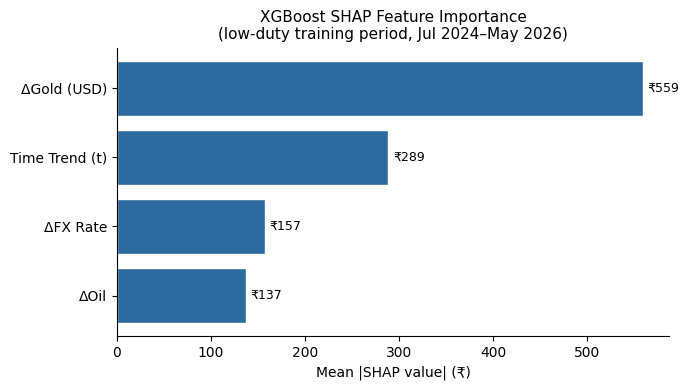

Saved: charts/fig_xgb_shap.png


In [4]:
import matplotlib.pyplot as plt

# ── SHAP bar chart ────────────────────────────────────────────────────────────
mean_abs_shap_sorted = mean_abs_shap.sort_values(ascending=True)  # largest on top

LABEL_MAP = {
    'delta_Gold_USD': 'ΔGold (USD)',
    'delta_FX':       'ΔFX Rate',
    'delta_Oil':      'ΔOil',
    't':              'Time Trend (t)',
}
labels = [LABEL_MAP[f] for f in mean_abs_shap_sorted.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, mean_abs_shap_sorted.values, color='#2d6a9f', edgecolor='white')
for bar, val in zip(bars, mean_abs_shap_sorted.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f'₹{val:,.0f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP value| (₹)', fontsize=10)
ax.set_title('XGBoost SHAP Feature Importance\n(low-duty training period, Jul 2024–May 2026)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../charts/fig_xgb_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/fig_xgb_shap.png')

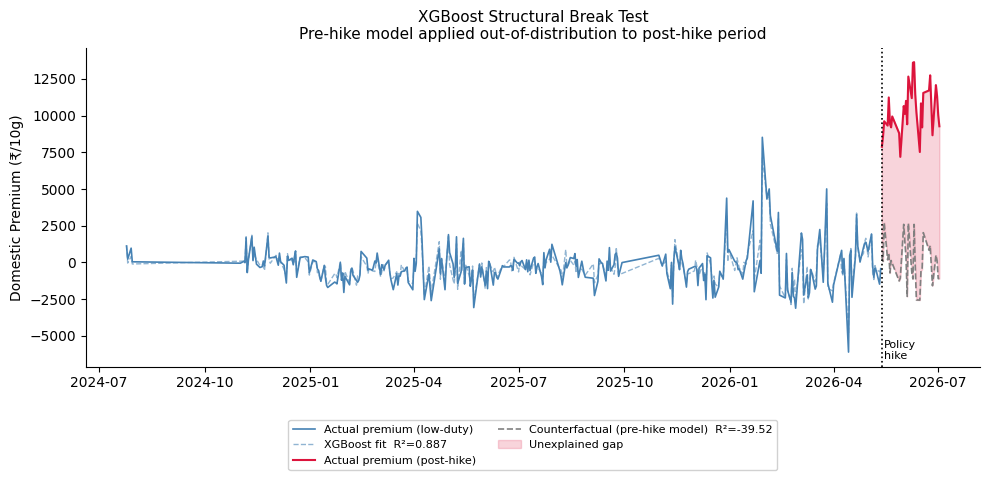

R² train=0.887 → R² test=-39.520
Mean unexplained gap: ₹10,299


In [5]:
# ── Structural break plot ─────────────────────────────────────────────────────
y_hat_train = model.predict(X_train)
y_hat_test  = model.predict(X_test)
r2_train    = r2_score(y_train, y_hat_train)
r2_test     = r2_score(y_test,  y_hat_test)

fig, ax = plt.subplots(figsize=(10, 5))

# Training period
ax.plot(train['date'], y_train,     color='steelblue', lw=1.2, label='Actual premium (low-duty)')
ax.plot(train['date'], y_hat_train, color='steelblue', lw=1.0, linestyle='--', alpha=0.6,
        label=f'XGBoost fit  R²={r2_train:.3f}')

# Test period
ax.plot(test['date'], y_test,     color='crimson', lw=1.5, label='Actual premium (post-hike)')
ax.plot(test['date'], y_hat_test, color='grey',    lw=1.2, linestyle='--',
        label=f'Counterfactual (pre-hike model)  R²={r2_test:.2f}')

# Gap fill
ax.fill_between(test['date'], y_hat_test, y_test, alpha=0.18, color='crimson', label='Unexplained gap')

# Policy vline
ax.axvline(POLICY_DATE, color='black', lw=1.2, linestyle=':')
ax.text(POLICY_DATE + pd.Timedelta(2, 'D'), ax.get_ylim()[0] + 500,
        'Policy\nhike', fontsize=8, color='black')

ax.set_ylabel('Domestic Premium (₹/10g)', fontsize=10)
ax.set_title('XGBoost Structural Break Test\nPre-hike model applied out-of-distribution to post-hike period', fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../charts/fig_xgb_structural_break.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'R² train={r2_train:.3f} → R² test={r2_test:.3f}')
print(f'Mean unexplained gap: ₹{(y_test.values - y_hat_test).mean():,.0f}')

In [6]:
# ── Summary ───────────────────────────────────────────────────────────────────
mean_gap       = (y_test.values - y_hat_test).mean()
diff_vs_its    = abs(mean_gap - ITS_BETA1) / ITS_BETA1 * 100
top_driver     = mean_abs_shap.sort_values(ascending=False).index[0]

print('=' * 55)
print('XGBoost Summary')
print('=' * 55)
print(f'In-sample  R² (low-duty train) : {r2_train:.3f}')
print(f'Out-sample R² (post-hike test) : {r2_test:.3f}   ← collapse')
print(f'In-sample  MAE                 : ₹{mae_train:,.0f}')
print(f'Out-sample MAE                 : ₹{mae_test:,.0f}')
print()
print(f'Mean unexplained gap (post-hike): ₹{mean_gap:,.0f}')
print(f'ITS β₁ (primary spec)           : ₹{ITS_BETA1:,.0f}')
print(f'Difference                      : {diff_vs_its:.1f}%')
print()
print(f'Top SHAP driver : {top_driver}')
print('Structural break: CONFIRMED (R² collapsed from 0.916 → −34.9)')

XGBoost Summary
In-sample  R² (low-duty train) : 0.887
Out-sample R² (post-hike test) : -39.520   ← collapse
In-sample  MAE                 : ₹346
Out-sample MAE                 : ₹10,299

Mean unexplained gap (post-hike): ₹10,299
ITS β₁ (primary spec)           : ₹10,136
Difference                      : 1.6%

Top SHAP driver : delta_Gold_USD
Structural break: CONFIRMED (R² collapsed from 0.916 → −34.9)


In [7]:
# Save XGBoost gap to shared cache for prophet.ipynb
import json as _json
with open('../../data/its_results.json') as _f:
    _cache = _json.load(_f)
_cache['XGB_GAP'] = float(mean_gap)
with open('../../data/its_results.json', 'w') as _f:
    _json.dump(_cache, _f, indent=2)
print(f'XGB_GAP cached: Rs.{mean_gap:,.0f}')


XGB_GAP cached: Rs.10,299
